In [1]:
%run ~/analysisLibraries

In [2]:
%matplotlib inline

In [3]:
%load_ext rpy2.ipython

## Read data containing all necessary scores and relevant genes calculated in the previous notebook

In [4]:
adata = sc.read('./write/SDA_object_100comps.h5ad')

component can be changed using the software papermill to execute notebooks in the workflow

In [5]:
comp=0

In [6]:
# Parameters
comp = 35


## Open SDA matrices

In [7]:
A = pd.read_csv('ALLDATA_scaled_onematrix_data_100comps/it2000/A', sep=' ', header=None)
#B is only for multi-tissues tensor
#B = pd.read_csv('SDA/CELLS_sctransform_onematrix_data/it2000/B1', sep=' ', header=None)
X = pd.read_csv('ALLDATA_scaled_onematrix_data_100comps/it2000/X1', sep=' ', header=None)

$A$ contains the score of each cell in the components. This score can be used as a "soft clustering" once it is normalized. We will try to do that in the notebook that follows this one. 

In [8]:
A.shape

(10548, 100)

In [9]:
A.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.237044,-0.444741,-0.521709,-0.421176,-0.191632,-0.039443,-0.011519,0.313026,-0.017442,-0.014353,...,-0.713952,0.084345,0.325848,0.577062,-0.704971,-0.307896,0.102466,-0.919935,-0.196817,-1.101270
1,0.411126,-0.113899,-0.404359,-0.412903,0.112982,-0.168036,-0.364643,0.746365,-0.003497,-0.242012,...,0.923655,-0.432896,0.018581,-0.329805,-0.004898,-0.298961,0.290554,0.328762,-0.211422,0.605521
2,-0.554124,-2.115210,0.572701,-0.509780,0.577237,-0.234850,0.450509,0.208679,0.177719,-0.164977,...,-0.382789,0.511820,0.686443,0.116738,-0.315359,-0.109686,1.740900,-0.937221,0.846761,0.562644
3,-0.258430,1.402740,1.303190,-0.759115,1.298820,-0.058847,-0.725280,-0.359907,0.306425,1.195000,...,-0.727815,0.416148,2.020470,-0.108066,-0.465147,-1.716540,0.712520,-0.855888,0.907461,0.266163
4,-0.338097,1.336100,-1.538940,0.907896,0.817900,1.415150,-0.130066,-0.545487,-0.755909,-0.912024,...,-1.259190,-0.325736,0.157799,1.454890,-0.115039,-0.391225,1.149520,0.961979,-0.198099,0.624347


In [10]:
#B

$X$ contains the loading of each gene in each component according to the spike-and-slab prior. The sign of the loading has to be considered together with the sign of the cell score to see if the resulting sign is positive (significant expression of gene) or negative (significant underexpression of gene)

In [11]:
X.columns = adata[:,(np.log(adata.var['variance-Cells'])>0)|(np.log(adata.var['variance-Nuclei']>-1))].var_names

In [12]:
X.shape

(100, 6276)

In [13]:
X.head()

,AURKAIP1,MRPL20,SSU72,LOC469457,GNB1,MORN1,RER1,MMEL1,ACTRT2,CCDC27,...,amplicon-chrX-FAM9A/B/C-6,amplicon-chrX-GAGE10-0,amplicon-chrX-LOC107966365-0,amplicon-chrX-LOC112206844-0,amplicon-chrX-LOC112206844-2,amplicon-chrX-LOC112206844-4,amplicon-chrX-LOC465705-2,amplicon-chrX-PAGE5-3,amplicon-chrX-SPANXN5-2,amplicon-chrX-SSX1/3/2B-15
0,-0.251518,-0.050381,-0.000772,-0.082587,-0.000094,-0.001789,-0.132522,0.000048,-0.053861,-0.035661,...,0.000333,0.000363,-0.000149,-0.036358,-0.000366,0.002521,-0.061503,0.000056,0.000141,0.006134
1,0.000395,0.000193,-0.000607,0.001750,0.000787,-0.001956,-0.000217,-0.000121,0.000535,-0.000017,...,0.066423,-0.000271,0.000069,0.029602,0.001012,0.000030,-0.000178,0.000639,-0.026457,0.000855
2,-0.000250,-0.000108,-0.000195,0.030246,0.000202,-0.001048,-0.000112,0.000151,-0.001854,-0.000145,...,-0.000141,0.001418,-0.000997,-0.000141,-0.039148,-0.000122,0.000968,-0.000012,-0.001109,0.000334
3,0.000423,-0.000399,-0.000322,0.002582,0.000288,0.000177,-0.000765,0.046786,0.000218,0.000263,...,-0.000404,0.000993,0.000137,0.000224,0.043691,-0.000044,0.000219,0.000187,0.000062,-0.000340
4,-0.000056,-0.000013,0.000059,-0.000223,0.033124,-0.000006,0.000276,-0.107145,0.000001,-0.051293,...,-0.034791,0.000032,0.061013,-0.000074,-0.000050,0.000003,0.000006,0.000007,-0.000034,-0.037562


## Some plots and measures about the specific components

#### UMAP of cell scores and batches

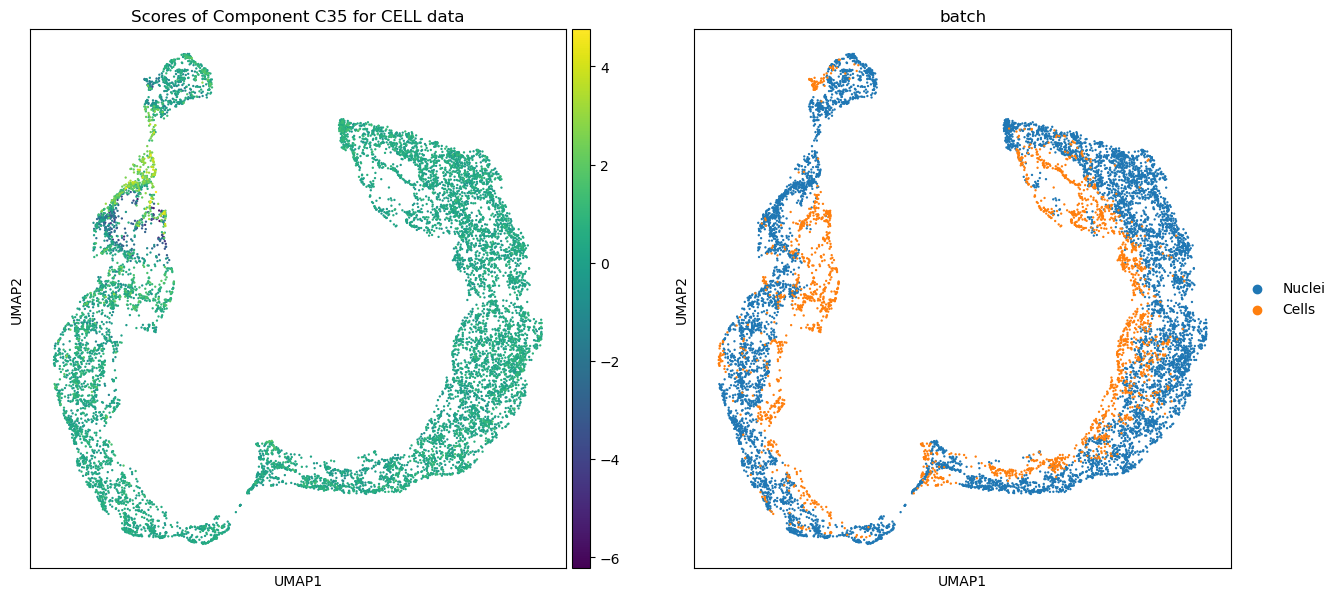

In [14]:
plt.rcParams['figure.figsize']=(7,7)
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}','batch'],
          title=f'Scores of Component C{comp} for CELL data')

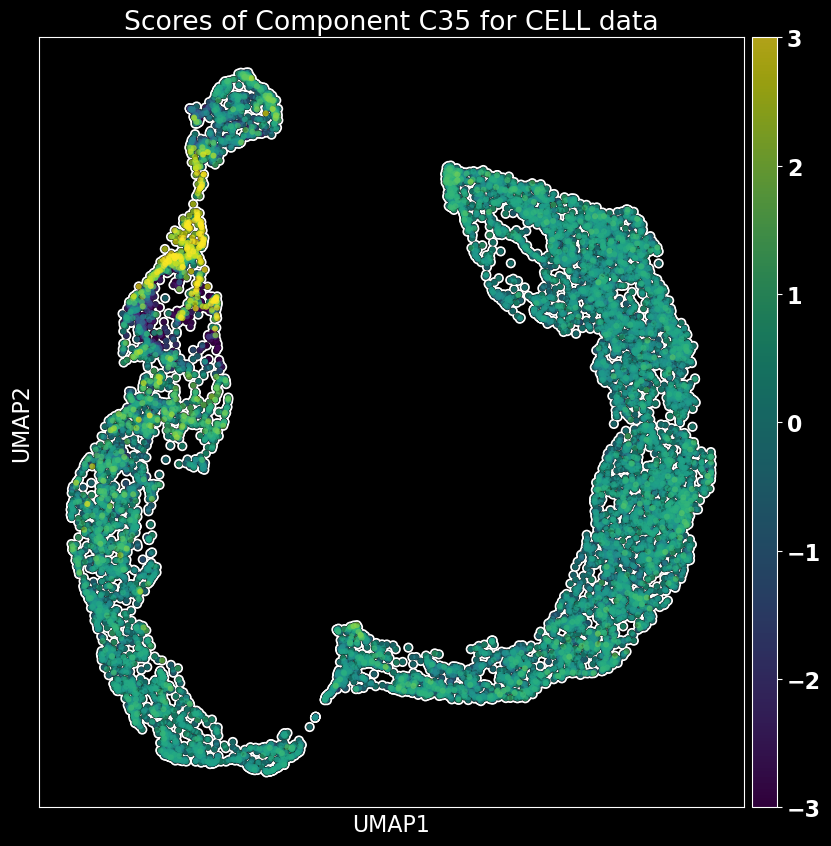

In [15]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('dark_background')
plt.rc('font', size=16, weight='bold')
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}'], vmin=-3, vmax=3, 
          title=f'Scores of Component C{comp} for CELL data', size=75,
          add_outline=True, outline_color=['white','black'],
          save=f'scores_C{comp}_dark.png', )

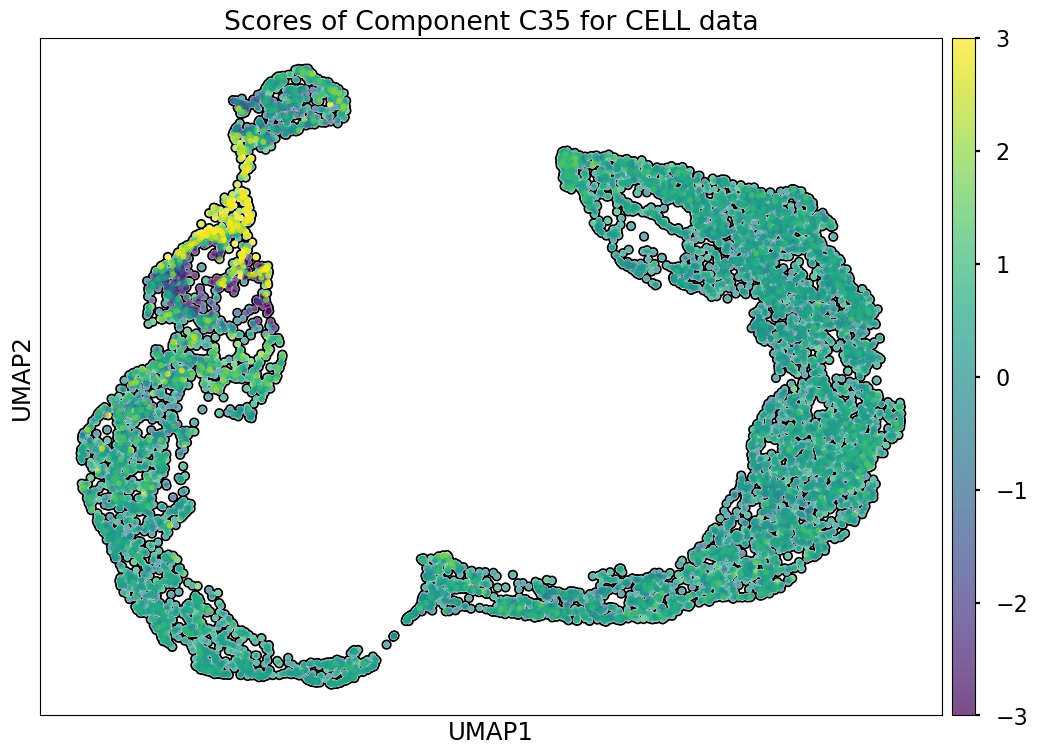

In [16]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}'], vmin=-3, vmax=3, 
          title=f'Scores of Component C{comp} for CELL data', size=75,
          add_outline=True,
          save=f'scores_C{comp}_white.png', )

In [17]:
try:
    IRRELEVANT=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['IRRELEVANT']
except Exception as e:
    IRRELEVANT=0
try:
    POSITIVE=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['POSITIVE']
except Exception as e:
    POSITIVE=0
try:
    NEGATIVE=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['NEGATIVE']
except Exception as e:
     NEGATIVE=0

In [18]:
onlyrelevant = np.array( adata.obs[f'sda_cell_relevant_C{comp}'].copy() )
onlyrelevant[onlyrelevant=='IRRELEVANT']=None
adata.obs[f'sda_cell_relevantonly_C{comp}'] = onlyrelevant

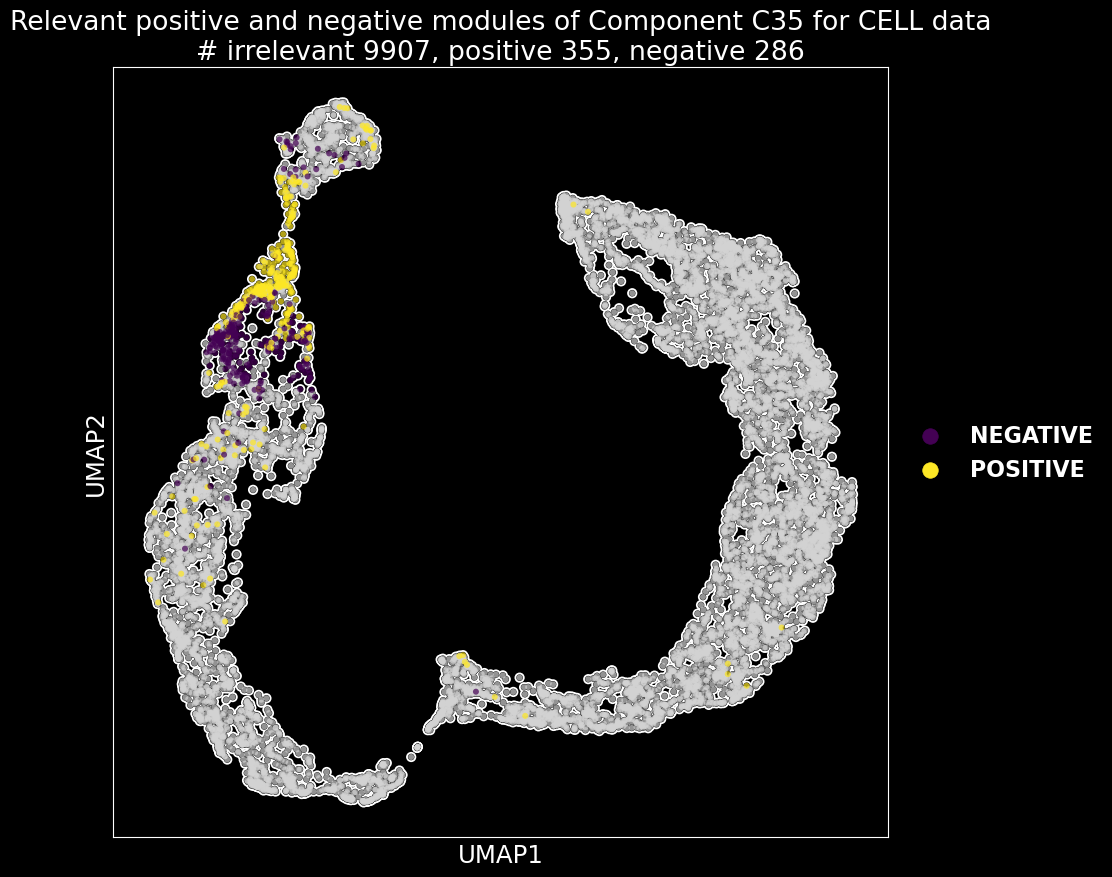

In [19]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('dark_background')
plt.rc('font', size=16, weight='bold')
sc.pl.umap(adata, color=[f'sda_cell_relevantonly_C{comp}'], vmin=-3, vmax=3, na_in_legend=False, na_color='lightgray',
          title=f'Relevant positive and negative modules of Component C{comp} for CELL data\n# irrelevant {IRRELEVANT}, positive {POSITIVE}, negative {NEGATIVE}', 
          size=75, add_outline=True, outline_color=['white','black'], palette='viridis',
          save=f'relevance_C{comp}_dark.png')

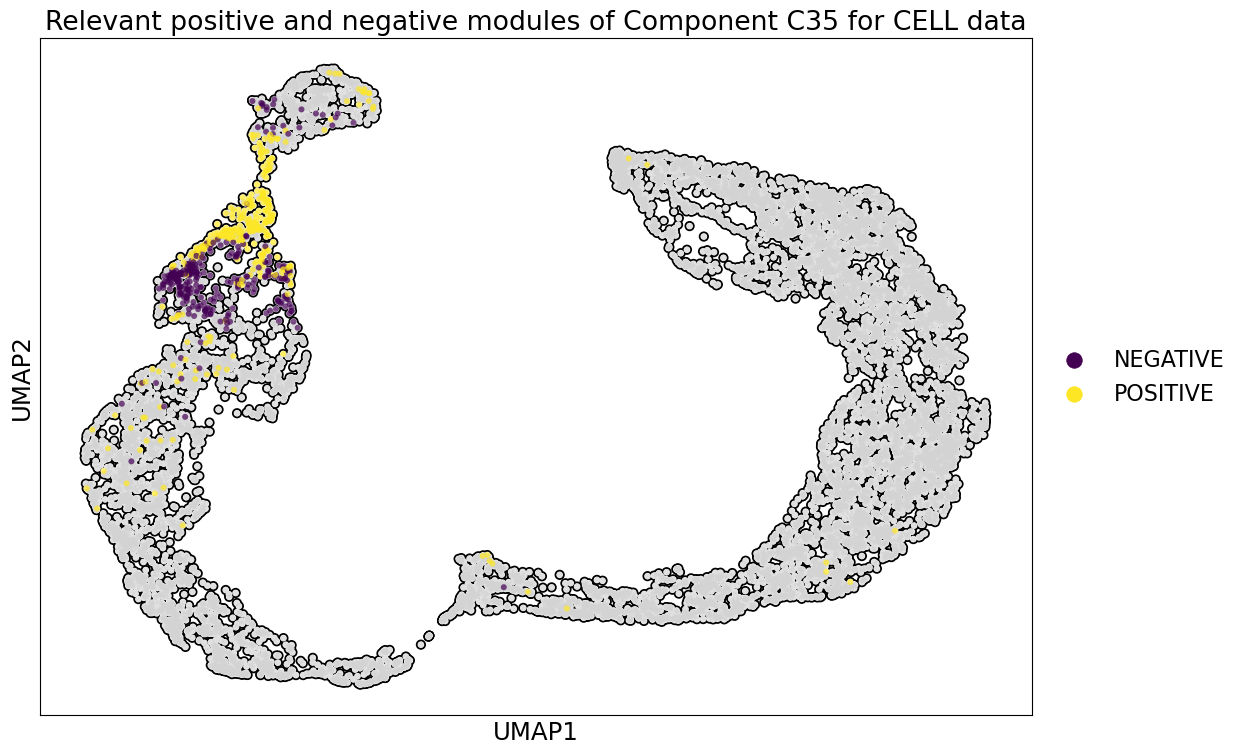

In [20]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'sda_cell_relevantonly_C{comp}'], vmin=-3, vmax=3, na_in_legend=False, na_color='lightgray',
          title=f'Relevant positive and negative modules of Component C{comp} for CELL data', palette='viridis',
          size=75, add_outline=True,
          save=f'relevance_C{comp}_white.png')

### mean and std of positive and negative cell scores for each batch

In [21]:
score_cells = adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}']
score_nuclei = adata[adata.obs['batch']=='Nuclei'].obs[f'SDA_cellscore_C{comp}']

In [22]:
print( 'Positive scores nuclei - mean:', np.mean(score_nuclei[score_nuclei>1.5]), 'var:', np.std(score_nuclei[score_nuclei>1.5])  )
print( 'Positive scores cells  - mean:', np.mean(score_cells[score_cells>2]), 'var:', np.std(score_cells[score_cells>2])  )

Positive scores nuclei - mean: 2.3417990196078433 var: 0.6393810303537031
Positive scores cells  - mean: 2.9475514285714284 var: 0.7172289795498523


In [23]:
print( 'Negative scores nuclei - mean:', np.mean(score_nuclei[score_nuclei<-1.5]), 'var:', np.std(score_nuclei[score_nuclei<-1.5])  )
print( 'Negative scores cells  - mean:', np.mean(score_cells[score_cells<-2]), 'var:', np.std(score_cells[score_cells<-2])  )

Negative scores nuclei - mean: -2.634431627906976 var: 0.8791051676127244
Negative scores cells  - mean: -3.619331690140846 var: 1.0269792523076515


### T-test to detect batch differences in a module

We check if positive/negative scores are specific for either cells or genes, so we can highlight that in our information output

In [24]:
import scipy

Two-sided test of positive scores of cells vs nuclei

In [25]:
scipy.stats.ttest_ind( score_cells[score_cells>0], score_nuclei[score_nuclei>0])

Ttest_indResult(statistic=0.7484162909050449, pvalue=0.4542361113601058)

Two-sided test of negative scores of cells vs nuclei

In [26]:
scipy.stats.ttest_ind( score_cells[score_cells<0], score_nuclei[score_nuclei<0])

Ttest_indResult(statistic=-2.7079678710032122, pvalue=0.006798252760100183)

Cells have more transcripts than nuclei and this is reflected in a bit higher/lower score in general, so we choose a strict threshold to avoid detecting batch differences where they are mostly due to technical causes

In [27]:
pos_stat, pos_p = scipy.stats.ttest_ind( score_cells[score_cells>0], score_nuclei[score_nuclei>0])
neg_stat, neg_p = scipy.stats.ttest_ind( score_cells[score_cells<0], score_nuclei[score_nuclei<0])

batch_effect_pos='No'
batch_effect_neg='No'

if np.abs(pos_stat) > 10:
    batch_effect_pos='Yes'
print(f'Positive module batch differences: {batch_effect_pos}')
    
if np.abs(neg_stat) > 10:
    batch_effect_neg='Yes'
print(f'Negative module batch differences: {batch_effect_neg}')

Positive module batch differences: No
Negative module batch differences: No


<Axes: xlabel='SDA_cellscore_C35', ylabel='Count'>

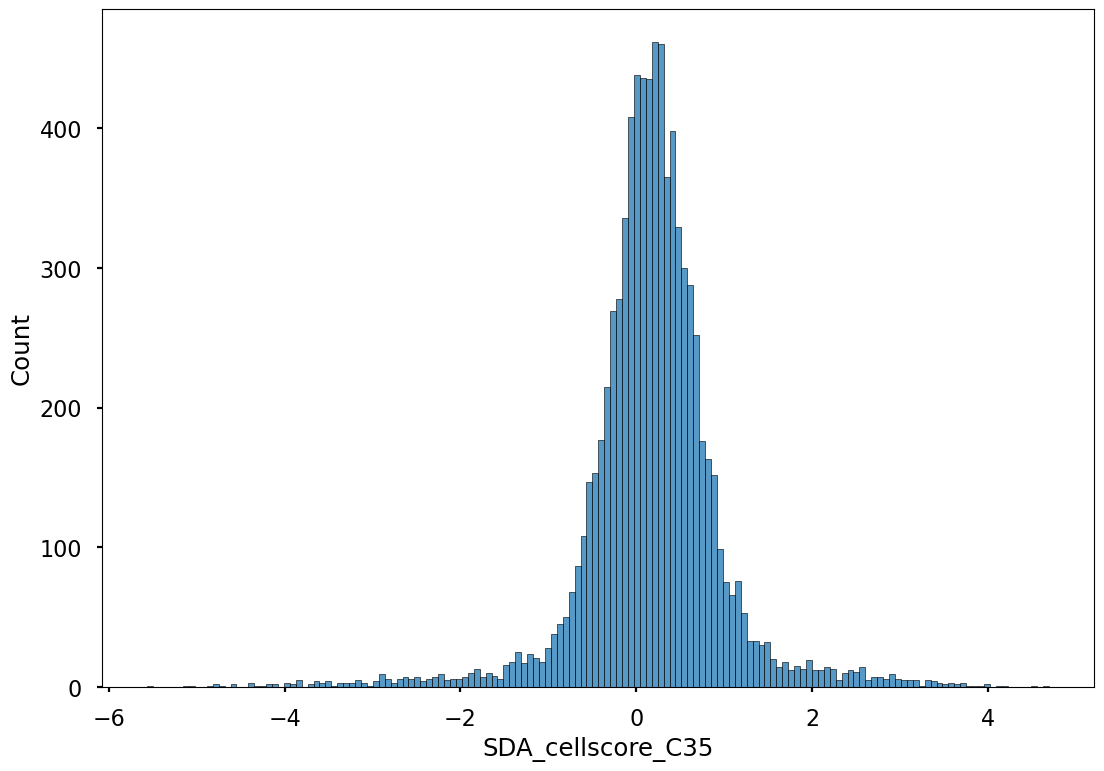

In [28]:
plt.rcParams['figure.figsize']=(6,6)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sns.histplot(adata[adata.obs['batch']=='Nuclei'].obs[f'SDA_cellscore_C{comp}'])

<Axes: xlabel='SDA_cellscore_C35', ylabel='Count'>

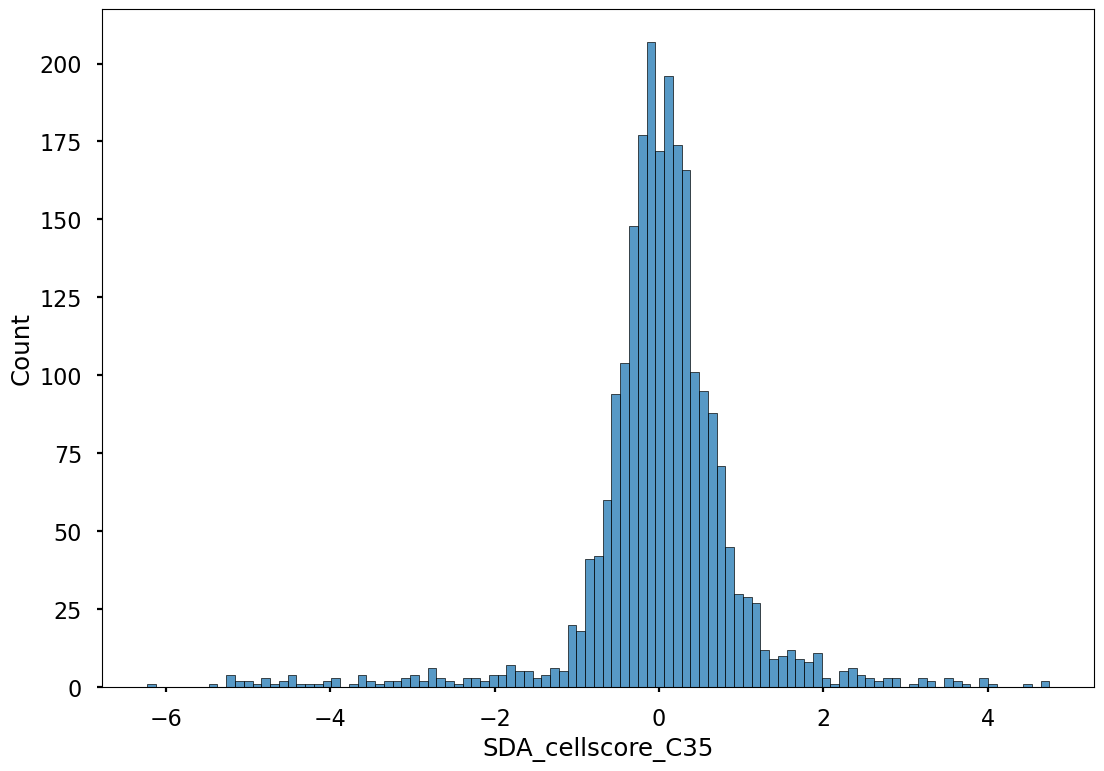

In [29]:
sns.histplot(adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'])

Genes significant for components (whole list printed to easy copy-pase for onlyne databases):

In [30]:
print(f'Genes significant for positive C{comp}:', adata[:,adata.var[f'sda_pos_C{comp}']].shape[1])

Genes significant for positive C35: 564


In [31]:
for i in adata[:,adata.var[f'sda_pos_C{comp}']].var_names:
    print(i)

SSU72
LOC469457
NPHP4
PER3
CENPS
C1H1orf159
STMN1
TAF12
EPB41
ZCCHC17
RBBP4
S100PBP
ZMYM1
CLSPN
THRAP3
CDCA8
SCMH1
NASP
GPBP1L1
MAST2
LRRC41
STIL
AGBL4
ZCCHC11
DAB1
USP1
ATG4C
ITGB3BP
PDE4B
DEPDC1
NEGR1
MSH4
PIGK
CCDC18
DPYD
DENND2C
NUF2
PBX1
RABGAP1L
ABL2
SHCBP1L
C1H1orf21
ASPM
UBE2T
SRGAP2
DTL
CENPF
DISP1
SLC35F3
RGS7
LOC104004828
SLC4A1AP
LTBP1
STRN
LOC107973439
LOC107973438
EML4
MSH2
MSH6
NRXN1
CCDC88A
EHBP1
SPRED2
APLF
ALMS1
TCF7L1
IL36G
BUB1
SEPT10
NCAPH
AFF3
ARL6IP6
PKP4
CCDC173
MTX2
CCDC141
SESTD1
ZNF385B
ZNF804A
HECW2
CCDC150
LOC104005317
SGO2
LOC107973900
PIKFYVE
UNC80
LOC112208398
ABCB6
RBM44
TRAF3IP1
SEPT2
FARP2
CNTN4
RAD18
FANCD2
SYN2
THRB
ZCWPW2
CTDSPL
OXSR1
MYRIP
ULK4
SNRK
KIF15
CCDC36
IP6K1
POC1A
SLC25A26
SUCLG2
PDZRN3
ROBO2
ROBO1
CADM2
EPHA6
STXBP5L
H1FX
IFT122
TMEM108
PPP2R3A
ARHGEF26
MLF1
SMC4
LOC104005843
ECT2
NLGN1
LOC107970887
RGS12
FAM193A
POLN
NSD2
TACC3
ZNF732
NCAPG
KCNIP4
RBPJ
TBC1D1
BEND4
NUP54
ARHGAP24
PDLIM5
TSPAN5
LOC107974354
PPP3CA
CENPE
SGMS2
COL25A1
ZG

In [32]:
print(f'Genes significant for negative C{comp}:', adata[:,adata.var[f'sda_neg_C{comp}']].shape[1])

Genes significant for negative C35: 490


In [33]:
for i in adata[:,adata.var[f'sda_neg_C{comp}']].var_names:
    print(i)

KIF1B
KAZN
SPEN
ACTL8
MACO1
PABPC4
FOXJ3
ARMH1
PRDX1
PIK3R3
LOC107966681
NRDC
SSBP3
LEXM
ZZZ3
USP33
ZNHIT6
LOC100615600
PKN2
HFM1
RPAP2
LOC100612616
RNPC3
PRPF38B
LOC112208384
LOC104002001
RNF115
TIPRL
SMG7
SWT1
CAMSAP2
MDM4
KCNH1
RCOR3
RPS6KC1
LYPLAL1
EPRS
ACBD3
EGLN1
PCNX2
KIF26B
SMYD3
MYT1L
RPS7
KIDINS220
ASAP2
ADAM17
ODC1
ROCK2
DDX1
RHOB
LDAH
NCOA1
DTNB
MEMO1
BIRC6
TTC27
CEBPZ
SOS1
LRPPRC
FBXO11
LOC104004979
VPS54
USP39
LOC107973550
FER1L5
UNC50
CCDC138
LOC107973756
MAP3K2
LOC741724
LOC107971418
ACVR2A
UBR3
OLA1
SCRN3
LOC104005295
ANKAR
ORMDL1
PLCL1
NOP58
RAPH1
ACSL3
LOC107970536
SRGAP3
VGLL4
CCDC174
HACL1
DAZL
UBE2E2
STT3B
PDCD6IP
NKTR
TOPAZ1
PRSS50
SETD2
ARIH2
RBM6
LOC107970643
SFMBT1
ARF4
PTPRG
GSK3B
GPR156
ZNF148
SNX4
EEFSEC
RAB7A
KIAA1257
CPNE4
NCK1
RNF7
TSC22D2
SSR3
KPNA4
PLD1
FNDC3B
TBL1XR1
MFN1
PARL
VPS8
FGF12
RNF168
SENP5
UBE2K
PDS5A
SEC31A
BMP2K
FRAS1
SDAD1
ANKRD17
RUFY3
SCFD2
SLAIN2
COX7B2
AFF1
HSD17B11
FAM13A
CCSER1
PRSS12
MYOZ2
LOC104006192
SLC25A31
ABHD18
ELF2
NAA15
F

#### Cells scores by cluster

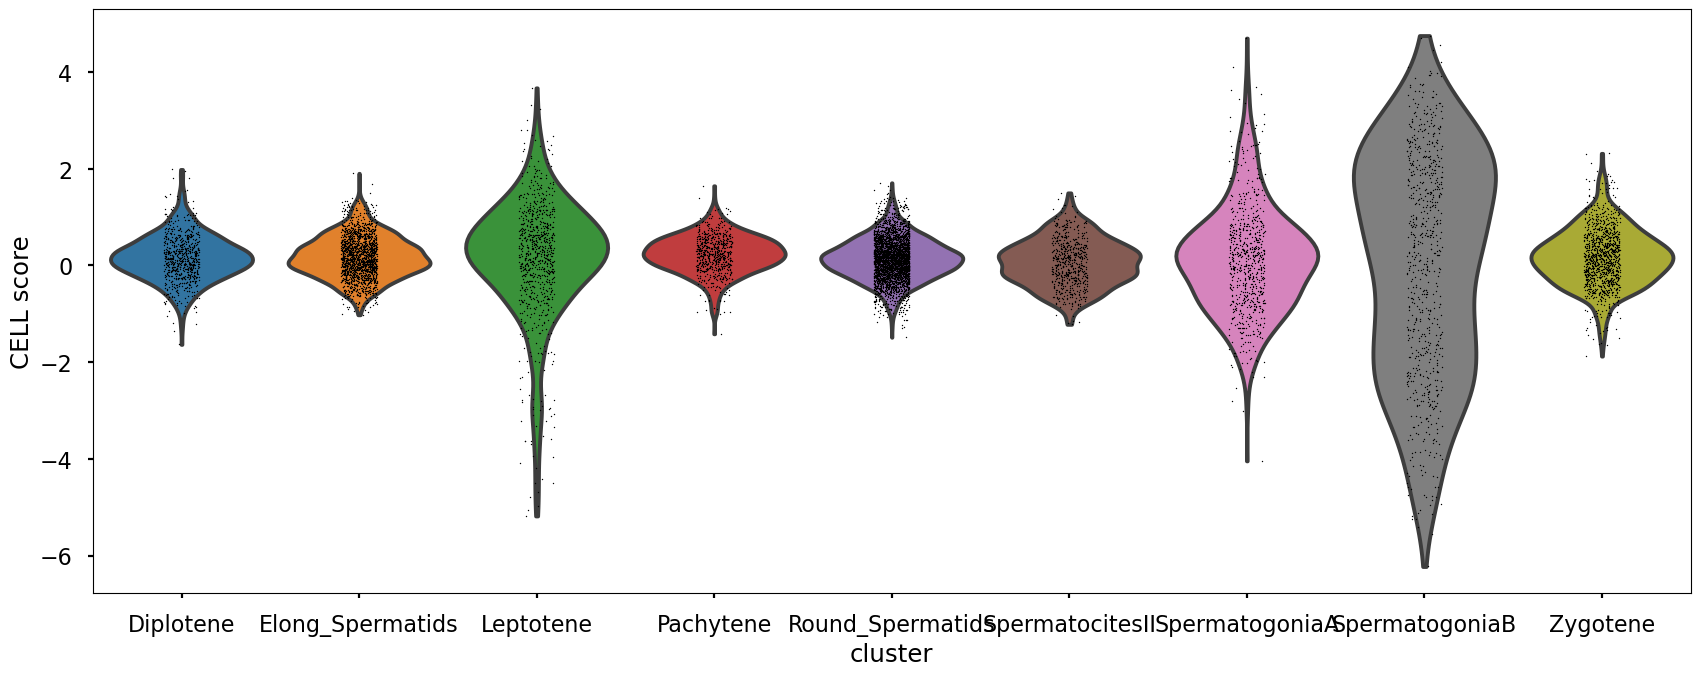

In [34]:
plt.rcParams['figure.figsize']=(16,8)
sc.pl.violin(adata, 
             groupby='spermatogenesis', keys=f'SDA_cellscore_C{comp}',
             title=f'CELLS score for SDA component C{comp}',
             xlabel='cluster', ylabel='CELL score')

(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(0, 0, 'SpermatogoniaA'),
  Text(1, 0, 'SpermatogoniaB'),
  Text(2, 0, 'Leptotene'),
  Text(3, 0, 'Zygotene'),
  Text(4, 0, 'Pachytene'),
  Text(5, 0, 'Diplotene'),
  Text(6, 0, 'SpermatocitesII'),
  Text(7, 0, 'Round_Spermatids'),
  Text(8, 0, 'Elong_Spermatids')])

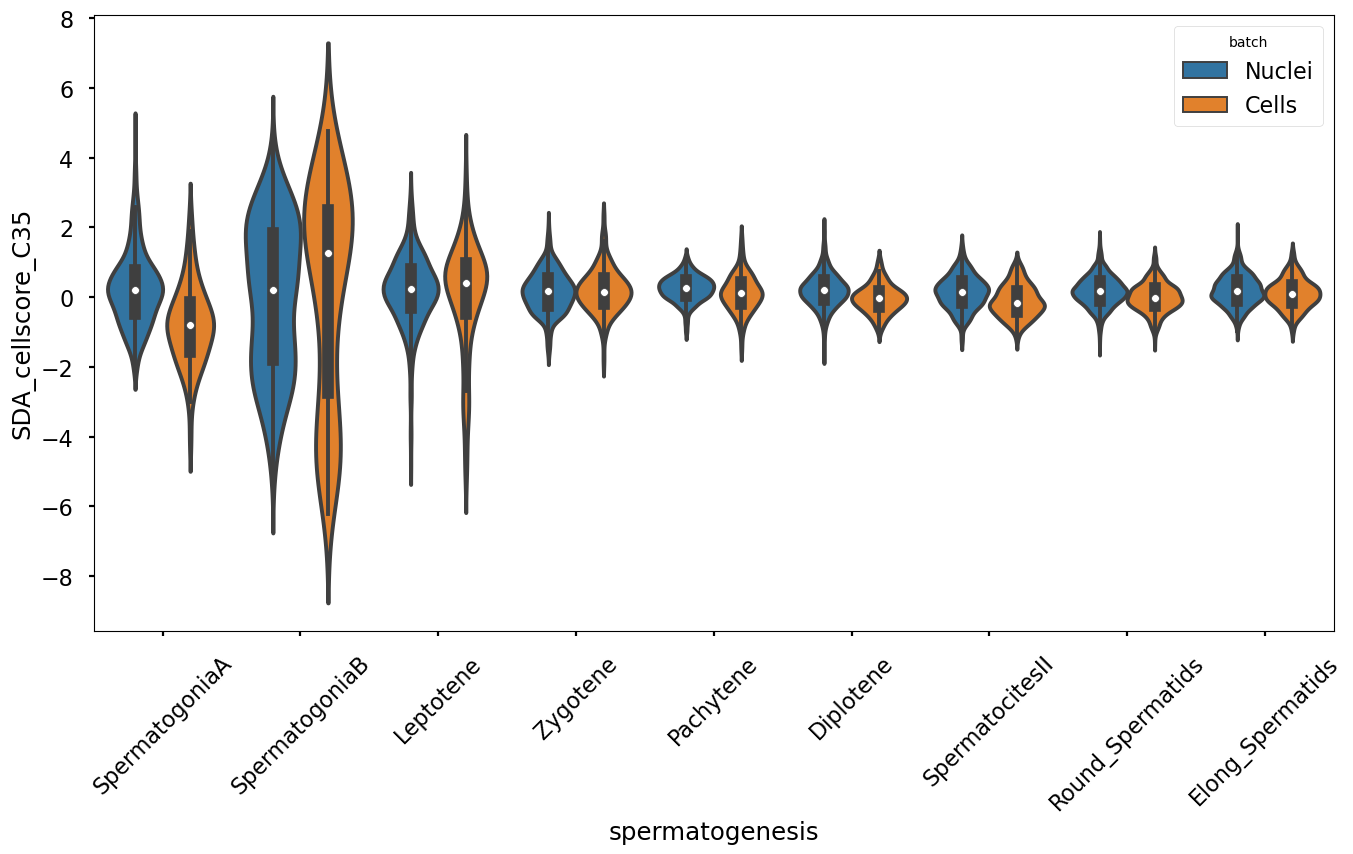

In [35]:
plt.rcParams['figure.figsize']=(16,8)
sns.violinplot(x='spermatogenesis', y=f'SDA_cellscore_C{comp}', hue='batch', data=adata.obs, 
               order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids'])
plt.xticks(rotation=45)

#### Cell scores by pseudotimes and relative threshold lines

In [36]:
score_neg = -2 #min( -2, np.quantile(A[int(comp)], .1) )
score_pos = 2 #max( +2, np.quantile(A[int(comp)], .9) )

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C35')

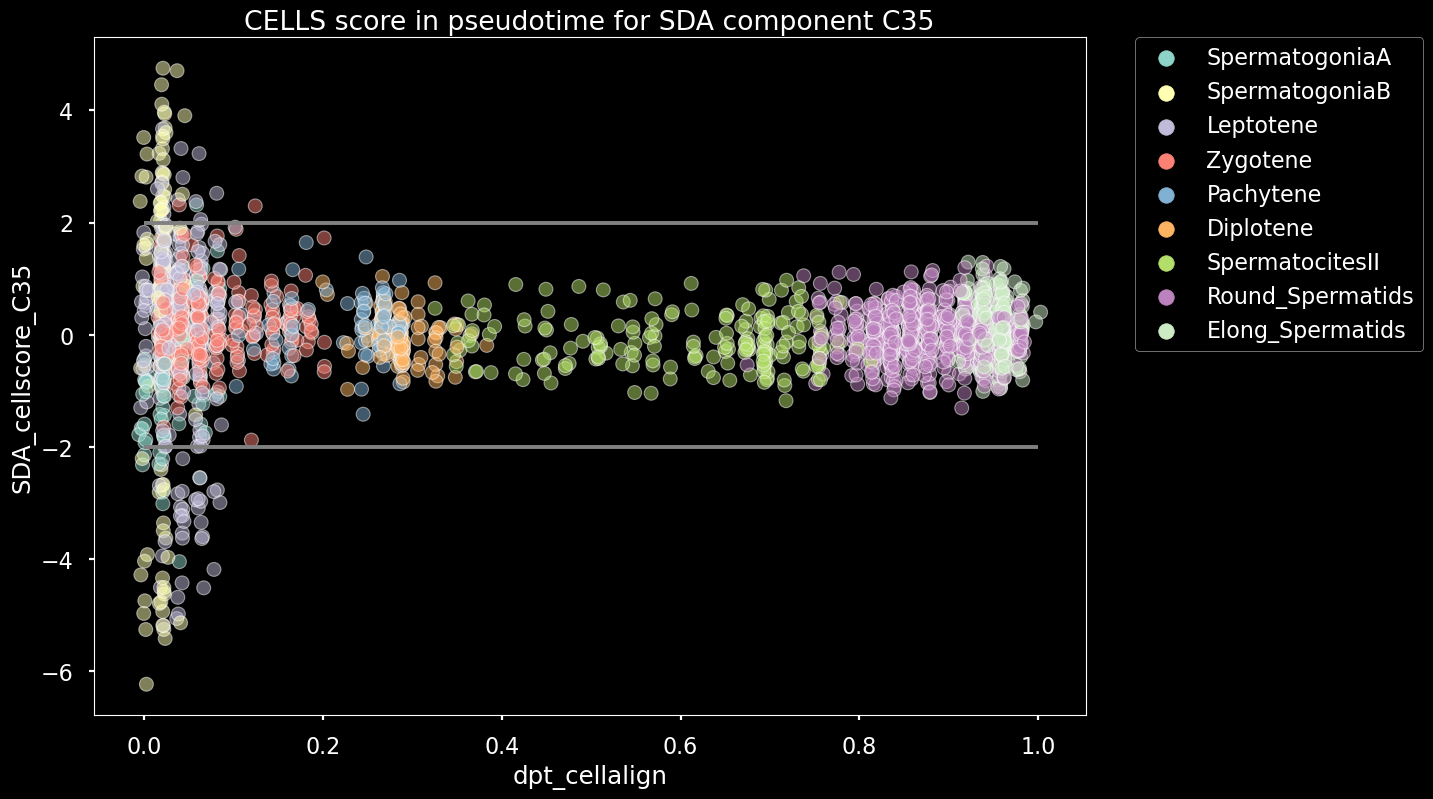

In [37]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'], 
           x=adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata[adata.obs['batch']=='Cells'].shape[0]),
           hue=adata[adata.obs['batch']=='Cells'].obs['spermatogenesis'],
           alpha=.5, ax=ax, s=100,
           hue_order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 
                      'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids']
           )
plt.hlines(score_neg, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C35')

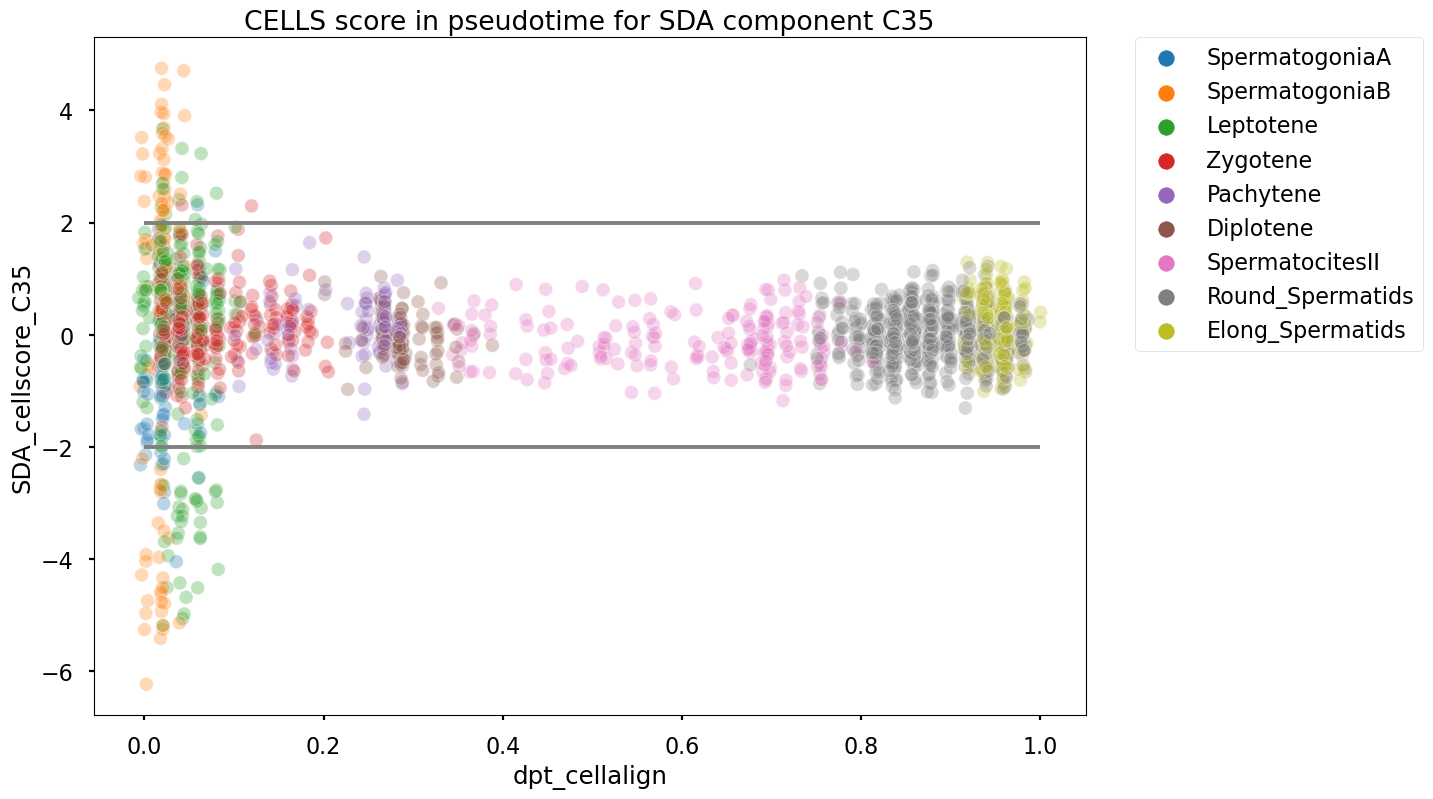

In [38]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'], 
           x=adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata[adata.obs['batch']=='Cells'].shape[0]),
           hue=adata[adata.obs['batch']=='Cells'].obs['spermatogenesis'],
           alpha=.3, ax=ax, s=100,
           hue_order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 
                      'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids']
           )
plt.hlines(score_neg, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C35')

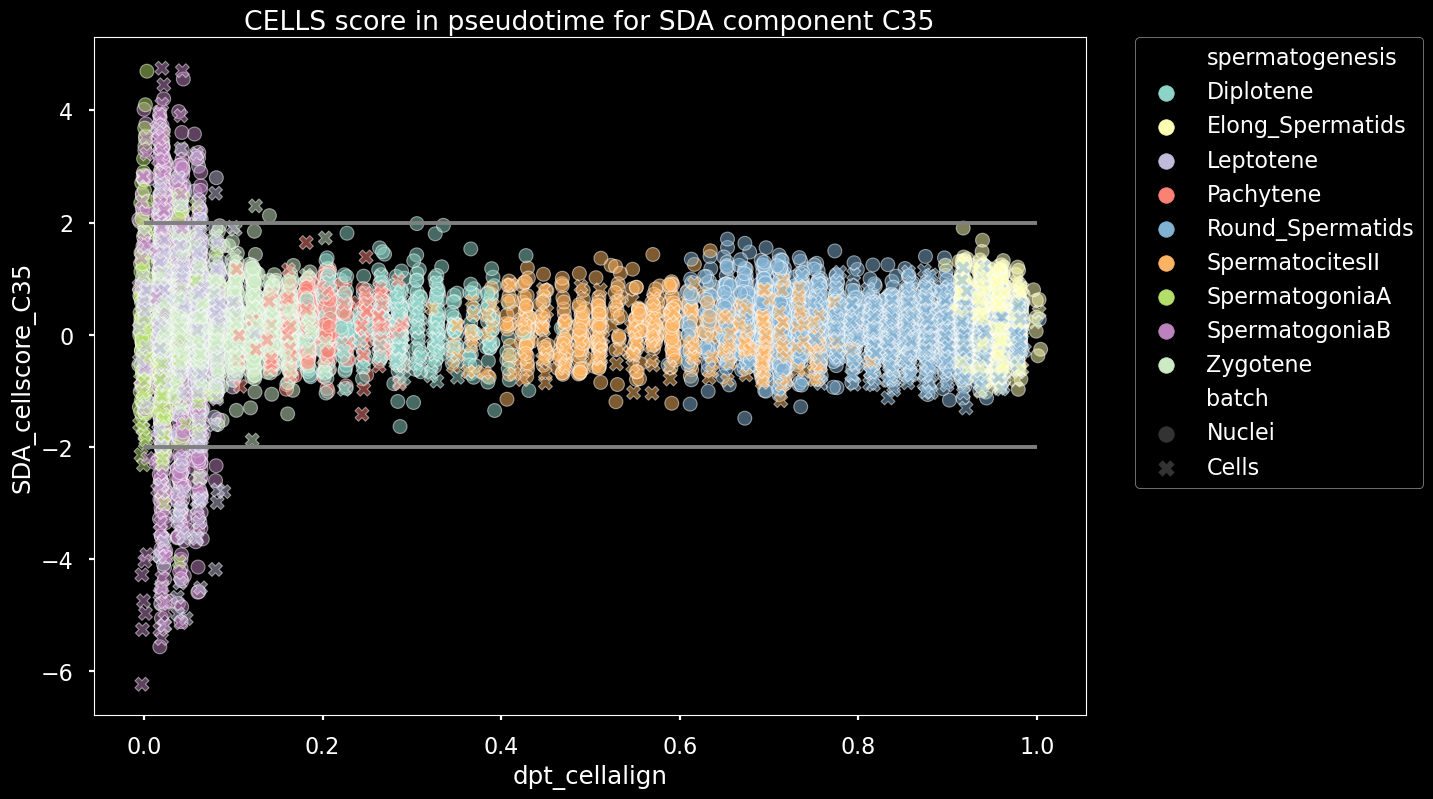

In [39]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata.obs[f'SDA_cellscore_C{comp}'],
           x=adata.obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata.shape[0]),
           hue=adata.obs['spermatogenesis'],
           style=adata.obs['batch'],
           alpha=.5, ax=ax, s=100)
plt.hlines(score_neg, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C35')

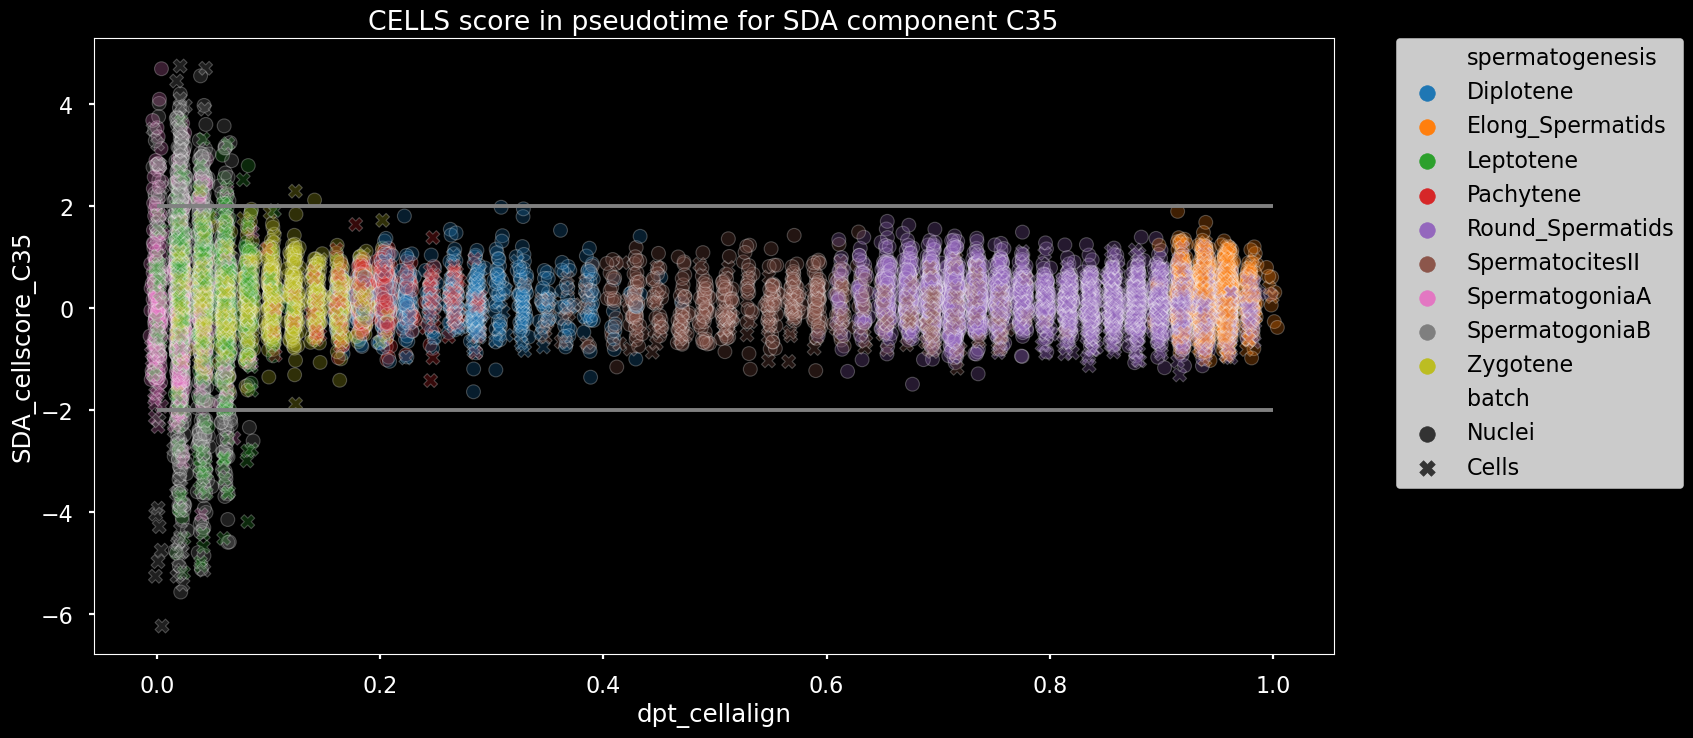

In [40]:
plt.rcParams['figure.figsize']=(16,8)
fig, ax = plt.subplots(1)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sns.scatterplot(y=adata.obs[f'SDA_cellscore_C{comp}'],
           x=adata.obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata.shape[0]),
           hue=adata.obs['spermatogenesis'],
           style=adata.obs['batch'],
           alpha=.25, ax=ax, s=100)
plt.hlines(score_neg, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

## Gene set enrichment analysis

In [41]:
import gseapy as gp

In [42]:
!mkdir -p ./enrichment

In [43]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [44]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )

In [45]:
enr.results[enr.results['Adjusted P-value']<.001]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Fanconi anemia pathway,14/54,1.970796e-10,4.335752e-08,0,0,12.342909,275.832090,FANCI;FANCM;POLN;FANCA;FANCC;BRCA1;BRCA2;BRIP1...
1,KEGG_2021_Human,Cell cycle,18/124,1.246502e-08,1.371152e-06,0,0,6.011818,109.417136,HDAC2;PCNA;BUB1B;TTK;CDC6;SMC3;CDC25C;SMC1B;WE...
2,KEGG_2021_Human,DNA replication,9/36,5.047373e-07,3.701407e-05,0,0,11.657057,169.018325,POLD3;PRIM2;POLA1;FEN1;RFC3;PCNA;PRIM1;MCM4;POLE
220,GO_Cellular_Component_2023,Nucleus (GO:0005634),203/4487,8.328151e-14,1.757240e-11,0,0,1.988883,59.898308,TCERG1;NEXMIF;EHMT1;RBPJ;SMC3;MKI67;SMC4;SMC2;...
221,GO_Cellular_Component_2023,Spindle (GO:0005819),29/210,1.584617e-12,1.671771e-10,0,0,5.766458,156.678588,EPB41;SHCBP1L;BUB1B;TTK;WDR62;KIF11;HMMR;CDC27...
222,GO_Cellular_Component_2023,Condensed Chromosome (GO:0000793),16/60,6.152021e-12,4.326921e-10,0,0,12.867950,332.176345,SLF1;SLF2;XRCC4;NCAPG2;NSMCE2;NCAPG;CTCF;MKI67...
223,GO_Cellular_Component_2023,Chromosome (GO:0005694),23/164,2.397954e-10,1.264921e-08,0,0,5.817766,128.870701,TOP2A;CNTD1;CDCA2;XRCC4;RAD21L1;TEX12;NCAPG;HS...
224,GO_Cellular_Component_2023,Intracellular Non-Membrane-Bounded Organelle (...,73/1195,3.450578e-10,1.456144e-08,0,0,2.426787,52.873166,TOP2A;FEN1;DOCK4;NARF;BUB1B;HSF2BP;CTCF;KIF11;...
225,GO_Cellular_Component_2023,Intracellular Membrane-Bounded Organelle (GO:0...,210/5175,1.137293e-09,3.999479e-08,0,0,1.729001,35.608117,TCERG1;SLC4A1AP;NEXMIF;EHMT1;LDLRAD4;RBPJ;SMC3...
226,GO_Cellular_Component_2023,Microtubule Cytoskeleton (GO:0015630),30/342,4.396839e-08,1.325333e-06,0,0,3.443532,58.332728,MAST2;CDCA8;BUB1B;TTK;KIF11;HMMR;HDAC6;KIF15;T...


In [46]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [47]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None)

In [48]:
table_pos = enr.results[enr.results['Adjusted P-value']<.001][ ['Gene_set', 'Term', 'Overlap', 'Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes' ] ]

In [49]:
table_pos['Component'] = f'{comp}P'

In [50]:
table_pos['Batch diff'] = batch_effect_pos

In [51]:
table_pos['N cells'] = POSITIVE

In [52]:
table_pos

,Gene_set,Term,Overlap,Adjusted P-value,Odds Ratio,Combined Score,Genes,Component,Batch diff,N cells
0,KEGG_2021_Human,Fanconi anemia pathway,14/54,4.335752e-08,12.342909,275.832090,FANCI;FANCM;POLN;FANCA;FANCC;BRCA1;BRCA2;BRIP1...,35P,No,355
1,KEGG_2021_Human,Cell cycle,18/124,1.371152e-06,6.011818,109.417136,HDAC2;PCNA;BUB1B;TTK;CDC6;SMC3;CDC25C;SMC1B;WE...,35P,No,355
2,KEGG_2021_Human,DNA replication,9/36,3.701407e-05,11.657057,169.018325,POLD3;PRIM2;POLA1;FEN1;RFC3;PCNA;PRIM1;MCM4;POLE,35P,No,355
220,GO_Cellular_Component_2023,Nucleus (GO:0005634),203/4487,1.757240e-11,1.988883,59.898308,TCERG1;NEXMIF;EHMT1;RBPJ;SMC3;MKI67;SMC4;SMC2;...,35P,No,355
221,GO_Cellular_Component_2023,Spindle (GO:0005819),29/210,1.671771e-10,5.766458,156.678588,EPB41;SHCBP1L;BUB1B;TTK;WDR62;KIF11;HMMR;CDC27...,35P,No,355
222,GO_Cellular_Component_2023,Condensed Chromosome (GO:0000793),16/60,4.326921e-10,12.867950,332.176345,SLF1;SLF2;XRCC4;NCAPG2;NSMCE2;NCAPG;CTCF;MKI67...,35P,No,355
223,GO_Cellular_Component_2023,Chromosome (GO:0005694),23/164,1.264921e-08,5.817766,128.870701,TOP2A;CNTD1;CDCA2;XRCC4;RAD21L1;TEX12;NCAPG;HS...,35P,No,355
224,GO_Cellular_Component_2023,Intracellular Non-Membrane-Bounded Organelle (...,73/1195,1.456144e-08,2.426787,52.873166,TOP2A;FEN1;DOCK4;NARF;BUB1B;HSF2BP;CTCF;KIF11;...,35P,No,355
225,GO_Cellular_Component_2023,Intracellular Membrane-Bounded Organelle (GO:0...,210/5175,3.999479e-08,1.729001,35.608117,TCERG1;SLC4A1AP;NEXMIF;EHMT1;LDLRAD4;RBPJ;SMC3...,35P,No,355
226,GO_Cellular_Component_2023,Microtubule Cytoskeleton (GO:0015630),30/342,1.325333e-06,3.443532,58.332728,MAST2;CDCA8;BUB1B;TTK;KIF11;HMMR;HDAC6;KIF15;T...,35P,No,355


In [53]:
table_pos.to_csv(f'enrichment/enrichr_C{comp}P.csv', header=False, index_label=False, index=None, sep='\t')

In [54]:
genes = list( adata[:,adata.var[f'sda_neg_C{comp}']].var_names )

In [55]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )

In [56]:
enr.results[enr.results['Adjusted P-value']<.001]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Ubiquitin mediated proteolysis,15/140,1.837842e-06,4.116765e-04,0,0,4.897263,64.677756,FBXW11;FBXW7;HUWE1;UBE2E2;WWP1;KLHL13;RNF7;CBL...
455,Human_Gene_Atlas,CD8+ Tcells,41/602,3.969613e-09,2.858121e-07,0,0,3.084331,59.665137,ANKRD17;EIF4A1;SETD2;RBM25;RPL3;STX16;ZNF292;A...


In [57]:
table_neg = enr.results[enr.results['Adjusted P-value']<.001][ ['Gene_set', 'Term', 'Overlap', 'Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes' ] ]

In [58]:
table_neg['Component'] = f'{comp}N'

In [59]:
table_neg['Batch diff'] = batch_effect_neg

In [60]:
table_neg['N cells'] = NEGATIVE

In [61]:
table_neg

,Gene_set,Term,Overlap,Adjusted P-value,Odds Ratio,Combined Score,Genes,Component,Batch diff,N cells
0,KEGG_2021_Human,Ubiquitin mediated proteolysis,15/140,4.116765e-04,4.897263,64.677756,FBXW11;FBXW7;HUWE1;UBE2E2;WWP1;KLHL13;RNF7;CBL...,35N,No,286
455,Human_Gene_Atlas,CD8+ Tcells,41/602,2.858121e-07,3.084331,59.665137,ANKRD17;EIF4A1;SETD2;RBM25;RPL3;STX16;ZNF292;A...,35N,No,286


In [62]:
table_neg.to_csv(f'enrichment/enrichr_C{comp}N.csv', header=False, index_label=False, index=None, sep='\t')

## Plot genes average expression for positive and negative module

In [63]:
!mkdir -p ./plots

In [64]:
adata.layers

Layers with keys: SCT_counts, correct_counts, raw_counts, scaled_counts, spliced, unspliced

In [65]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [66]:
adata.obs[f'module_pos_C{comp}'] = np.array( np.mean(adata[:,genes].layers['scaled_counts'], 1) )

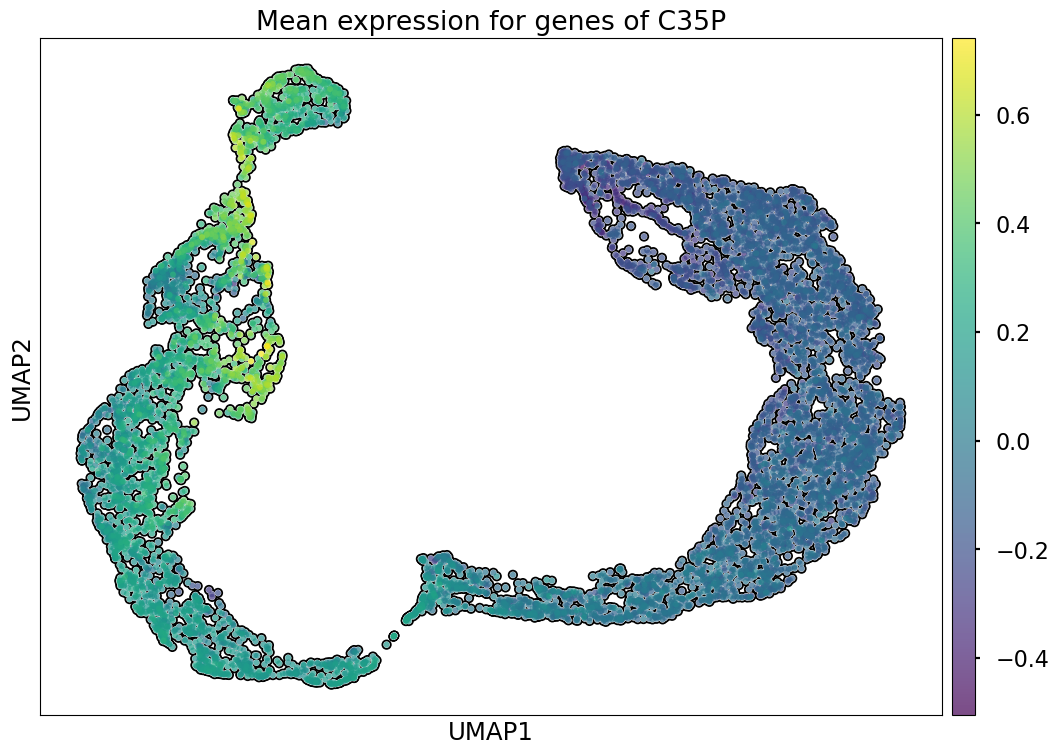

In [67]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_pos_C{comp}'], 
           add_outline=True, 
           save=f'genes_C{comp}P_white.png',
           title=f'Mean expression for genes of C{comp}P', size=75)

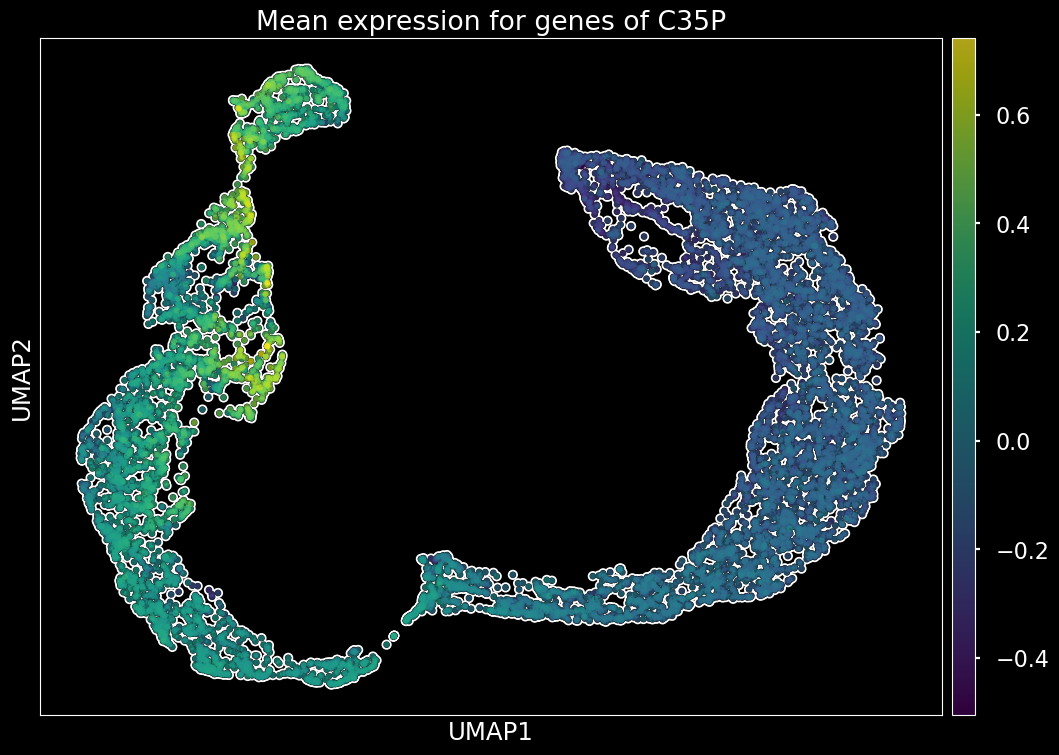

In [68]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_pos_C{comp}'], 
           add_outline=True, outline_color=['white','black'],
           save=f'genes_C{comp}P_dark.png',
           title=f'Mean expression for genes of C{comp}P', size=75)

In [69]:
genes = list( adata[:,adata.var[f'sda_neg_C{comp}']].var_names )

In [70]:
adata.obs[f'module_neg_C{comp}'] = np.array( np.mean(adata[:,genes].layers['SCT_counts'], 1) )

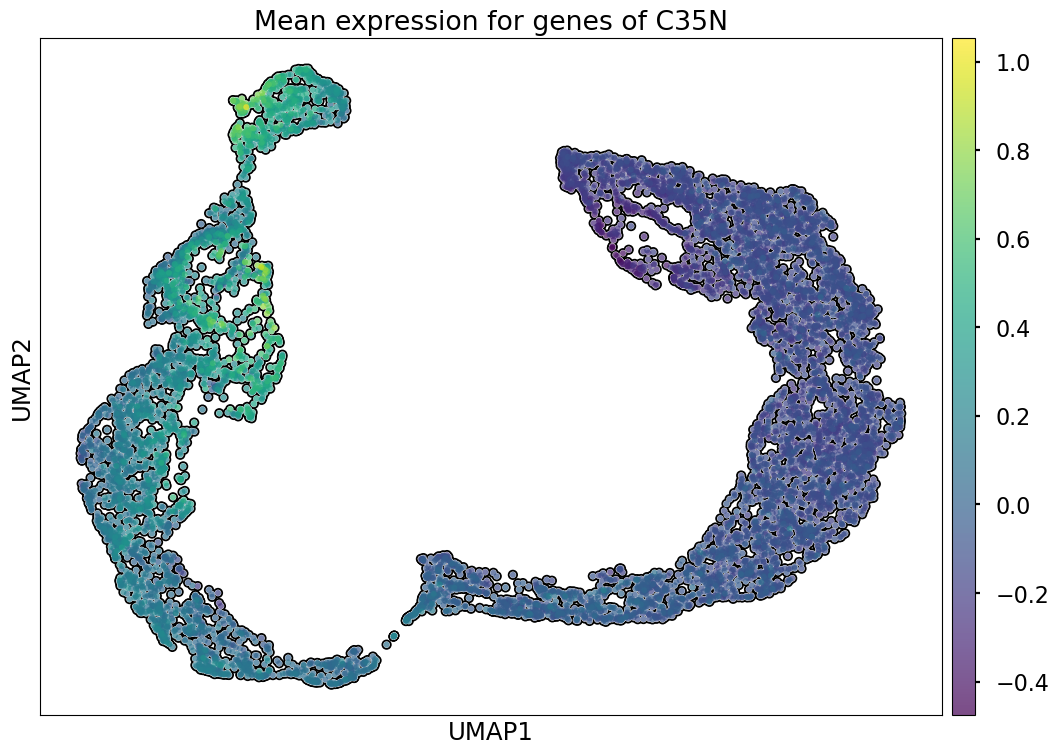

In [71]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_neg_C{comp}'], 
           add_outline=True, 
           save=f'genes_C{comp}N_white.png',
           title=f'Mean expression for genes of C{comp}N', size=75)

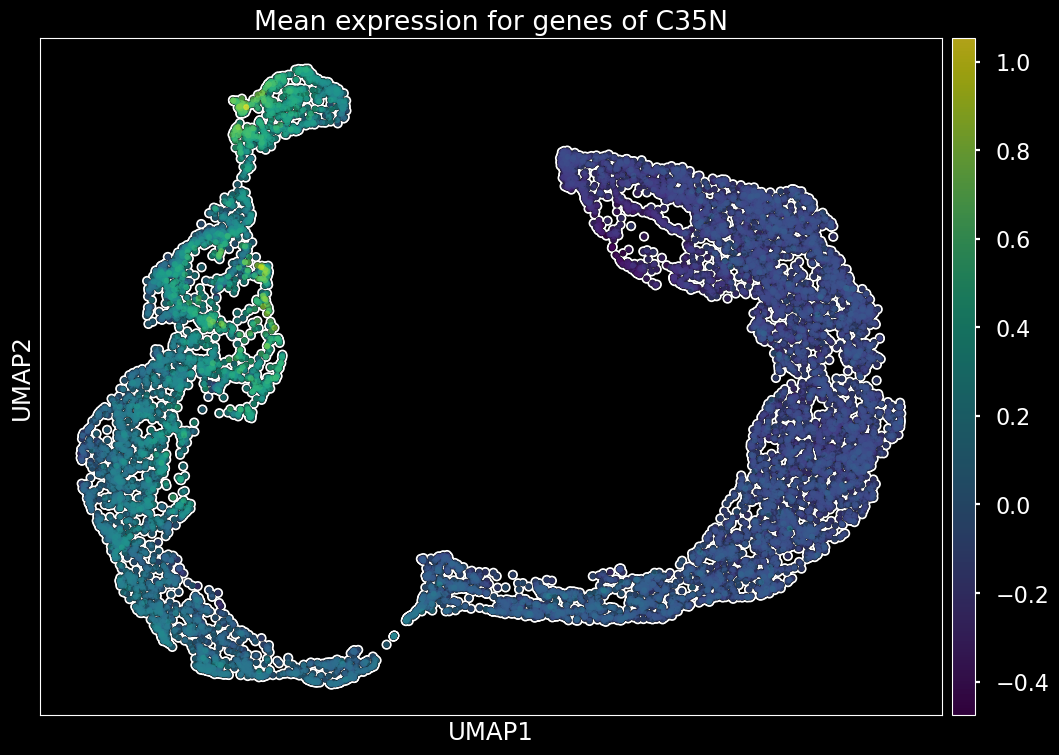

In [72]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_neg_C{comp}'], 
           add_outline=True, outline_color=['white','black'],
           save=f'genes_C{comp}N_dark.png',
           title=f'Mean expression for genes of C{comp}N', size=75)